In [14]:
print("AKHIL C")
print("24BAD007")

AKHIL C
24BAD007


# Scenario 2 – Movie Recommendation using NMF



## 1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
print(ratings.shape)
ratings.head()

(100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2. Create User-Item Matrix

In [2]:
train_data, test_data = train_test_split(
    ratings, test_size=0.2, random_state=42,
    stratify=pd.cut(ratings['rating'], bins=[0,2,3,4,5], labels=False)
)

user_item_matrix = train_data.pivot_table(index='userId', columns='movieId', values='rating')
print(f"Matrix shape: {user_item_matrix.shape}")
sparsity = user_item_matrix.isnull().sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1])
print(f"Sparsity: {sparsity:.2%}")

Matrix shape: (610, 8944)
Sparsity: 98.52%


## 3. Handle Missing Values

In [3]:
global_mean = user_item_matrix.stack().mean()
item_means  = user_item_matrix.mean(axis=0)

matrix_filled = user_item_matrix.copy()
for col in matrix_filled.columns:
    fill_val = item_means[col] if not pd.isna(item_means[col]) else global_mean
    matrix_filled[col] = matrix_filled[col].fillna(fill_val)

matrix_filled = matrix_filled.values
print(f"Global mean rating : {global_mean:.4f}")
print(f"Remaining zeros    : {(matrix_filled == 0).sum()}  (should be ~0 now)")

Global mean rating : 3.5015
Remaining zeros    : 0  (should be ~0 now)


## 4. Apply NMF Model

In [4]:
# k=20 gives better generalisation than 50 on sparse data;
# alpha_W/alpha_H add L2 regularisation to reduce overfitting.
k = 20
nmf = NMF(
    n_components=k,
    init='nndsvda',
    max_iter=1000,
    random_state=42,
    alpha_W=0.1,      # L2 regularisation on user factors
    alpha_H=0.1,      # L2 regularisation on item factors
    l1_ratio=0.0,     # pure L2
)
W = nmf.fit_transform(matrix_filled)
print(f"k = {k}")
print(f"Fitting done. Reconstruction error: {nmf.reconstruction_err_:.4f}")

k = 20
Fitting done. Reconstruction error: 349.7540


## 5. User-Feature and Item-Feature Matrices

In [5]:
H = nmf.components_
print(f"User-Feature matrix W: {W.shape}")
print(f"Item-Feature matrix H: {H.shape}")

User-Feature matrix W: (610, 20)
Item-Feature matrix H: (20, 8944)


## 6 & 7. Reconstruct Matrix and Predict Missing Values

In [6]:
reconstructed = np.dot(W, H)
reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
).clip(0.5, 5.0)

# Vectorized prediction — much faster than iterrows
test_subset = test_data[
    test_data['userId'].isin(reconstructed_df.index) &
    test_data['movieId'].isin(reconstructed_df.columns)
].copy()

user_idx = {u: i for i, u in enumerate(reconstructed_df.index)}
movie_idx = {m: j for j, m in enumerate(reconstructed_df.columns)}
rec_arr  = reconstructed_df.values

row_ids = test_subset['userId'].map(user_idx).values
col_ids = test_subset['movieId'].map(movie_idx).values
preds   = rec_arr[row_ids, col_ids]
actuals = test_subset['rating'].values

## Evaluation Metrics

In [7]:
rmse = np.sqrt(mean_squared_error(actuals, preds))
mae = mean_absolute_error(actuals, preds)
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

RMSE: 0.9707
MAE:  0.7600


In [8]:
def precision_recall_at_k(user_id, k=10, threshold=4.0):
    rated = train_data[train_data['userId'] == user_id]['movieId'].values
    user_preds = reconstructed_df.loc[user_id].drop(index=rated, errors='ignore')
    top_k = set(user_preds.nlargest(k).index)

    relevant = set(
        test_data[(test_data['userId'] == user_id) & (test_data['rating'] >= threshold)]['movieId'].values
    )
    if not relevant:
        return None, None
    hits = top_k & relevant
    return len(hits) / k, len(hits) / len(relevant)

precisions, recalls = [], []
for uid in reconstructed_df.index[:100]:
    p, r = precision_recall_at_k(uid, k=10)
    if p is not None:
        precisions.append(p)
        recalls.append(r)

print(f"Precision@10: {np.mean(precisions):.4f}")
print(f"Recall@10:    {np.mean(recalls):.4f}")

Precision@10: 0.0000
Recall@10:    0.0000


## 8. Generate Top-N Recommendations

In [9]:
def get_top_n(user_id, n=10):
    rated = train_data[train_data['userId'] == user_id]['movieId'].values
    user_preds = reconstructed_df.loc[user_id].drop(index=rated, errors='ignore')
    top_movies = user_preds.nlargest(n).index
    return movies[movies['movieId'].isin(top_movies)][['movieId', 'title']].set_index('movieId').loc[top_movies]

print("Top 10 recommendations for User 1 (NMF):")
get_top_n(1, 10)

Top 10 recommendations for User 1 (NMF):


,title
movieId,
40,"Cry, the Beloved Country (1995)"
53,Lamerica (1994)
99,Heidi Fleiss: Hollywood Madam (1995)
148,"Awfully Big Adventure, An (1995)"
299,Priest (1994)
467,Live Nude Girls (1995)
484,Lassie (1994)
495,In the Realm of the Senses (Ai no corrida) (1976)
496,What Happened Was... (1994)


In [10]:
# SVD metrics for comparison
from numpy.linalg import svd as np_svd

user_means = user_item_matrix.mean(axis=1)
matrix_centered = user_item_matrix.subtract(user_means, axis=0).fillna(0).values
U, sigma, Vt = np_svd(matrix_centered, full_matrices=False)
k_svd = 50
rec_svd = np.dot(U[:, :k_svd], np.dot(np.diag(sigma[:k_svd]), Vt[:k_svd, :]))
rec_svd_df = pd.DataFrame(
    rec_svd + user_means.values.reshape(-1, 1),
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
).clip(0.5, 5.0)

svd_preds = [rec_svd_df.loc[r['userId'], r['movieId']]
             if r['userId'] in rec_svd_df.index and r['movieId'] in rec_svd_df.columns
             else np.nan for _, r in test_subset.iterrows()]
svd_preds = np.array(svd_preds, dtype=float)
mask = ~np.isnan(svd_preds)

svd_rmse = np.sqrt(mean_squared_error(actuals[mask], svd_preds[mask]))
nmf_rmse = rmse

print(f"SVD RMSE: {svd_rmse:.4f}")
print(f"NMF RMSE: {nmf_rmse:.4f}")

SVD RMSE: 0.9182
NMF RMSE: 0.9707


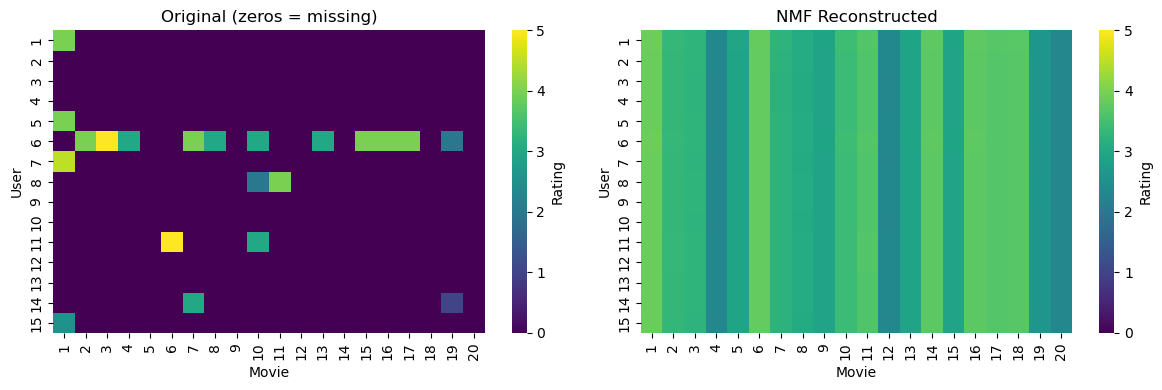

In [11]:
# Reconstruction comparison: original vs NMF reconstructed
subset_users = user_item_matrix.index[:15]
subset_movies = user_item_matrix.columns[:20]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
orig_sub = user_item_matrix.loc[subset_users, subset_movies].fillna(0)
rec_sub = reconstructed_df.loc[subset_users, subset_movies]

sns.heatmap(orig_sub, ax=axes[0], cmap='viridis', vmin=0, vmax=5, cbar_kws={'label': 'Rating'})
axes[0].set_title('Original (zeros = missing)')
axes[0].set_xlabel('Movie')
axes[0].set_ylabel('User')

sns.heatmap(rec_sub, ax=axes[1], cmap='viridis', vmin=0, vmax=5, cbar_kws={'label': 'Rating'})
axes[1].set_title('NMF Reconstructed')
axes[1].set_xlabel('Movie')
axes[1].set_ylabel('User')

plt.tight_layout()
plt.show()

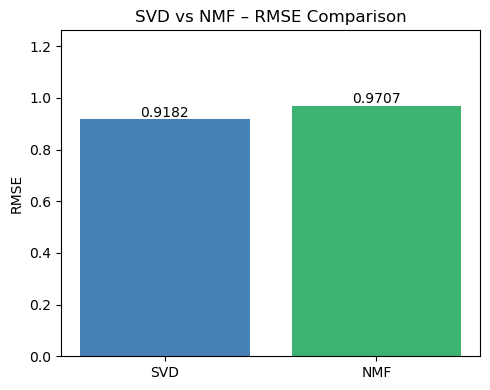

In [12]:
# SVD vs NMF RMSE comparison bar chart
plt.figure(figsize=(5, 4))
plt.bar(['SVD', 'NMF'], [svd_rmse, nmf_rmse], color=['steelblue', 'mediumseagreen'])
plt.ylabel('RMSE')
plt.title('SVD vs NMF – RMSE Comparison')
plt.ylim(0, max(svd_rmse, nmf_rmse) * 1.3)
for i, v in enumerate([svd_rmse, nmf_rmse]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.tight_layout()
plt.show()

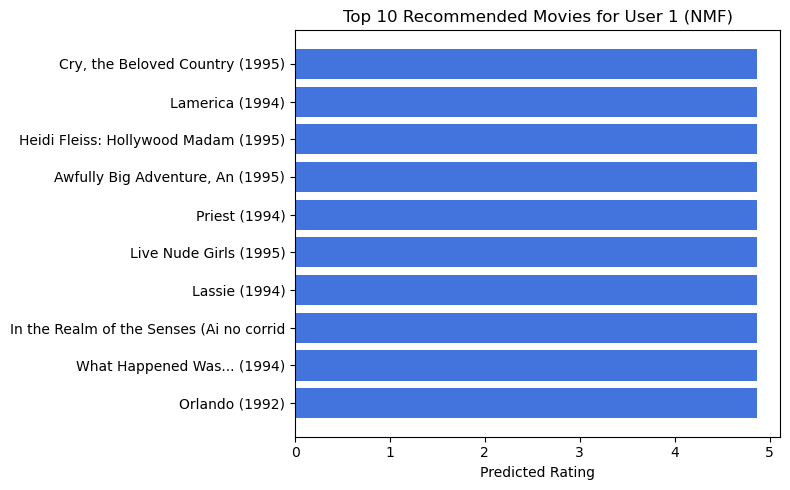

In [13]:
# Top recommended movies for user 1 (NMF)
top_recs = get_top_n(1, 10)
scores = reconstructed_df.loc[1, top_recs.index]

plt.figure(figsize=(8, 5))
plt.barh(top_recs['title'].str[:40].values[::-1], scores.values[::-1], color='#4374de')
plt.xlabel('Predicted Rating')
plt.title('Top 10 Recommended Movies for User 1 (NMF)')
plt.tight_layout()
plt.show()